# Data Loading and Preprocessing

In [1]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [2]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [6]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [7]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [8]:
df.dropna(inplace=True)

In [9]:
df.drop('customerID', axis=1, inplace=True)

In [10]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [11]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMethod     7032 non-null   object 
 17  

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


#EDA

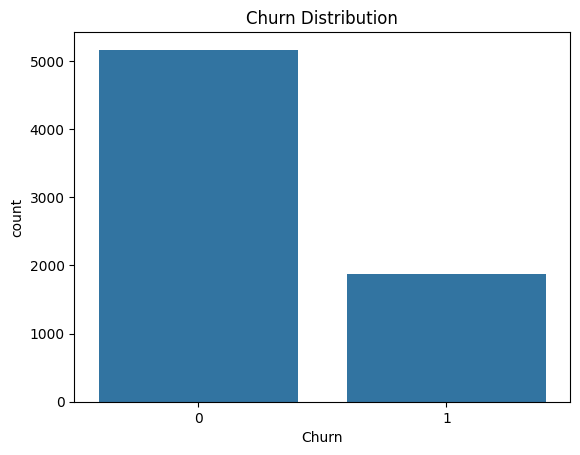

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

In [13]:
print("Only ~26% customers churn, indicating class imbalance. This suggests models must prioritize recall and F1-score over accuracy")

Only ~26% customers churn, indicating class imbalance. This suggests models must prioritize recall and F1-score over accuracy


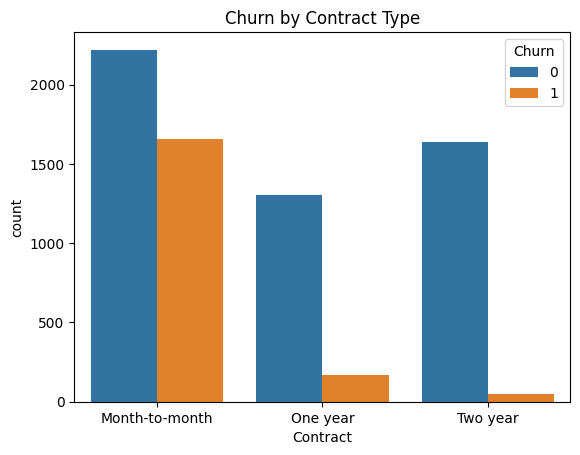

In [14]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Churn by Contract Type")
plt.show()

In [15]:
print("Customers without long-term commitment are significantly more likely to churn, suggesting contract incentives can improve retention")

Customers without long-term commitment are significantly more likely to churn, suggesting contract incentives can improve retention


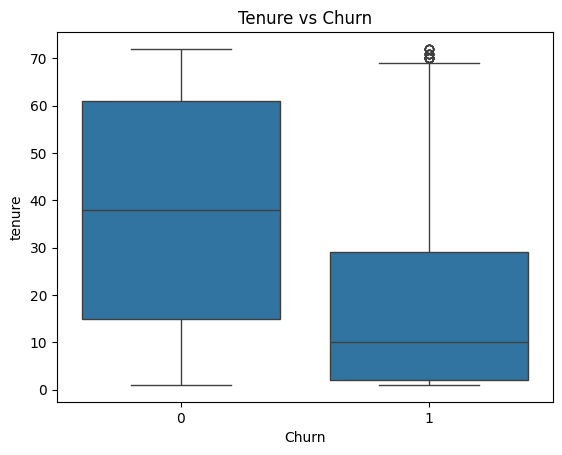

In [16]:
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Tenure vs Churn")
plt.show()

In [17]:
print("New customers churn more Loyal customers stay")

New customers churn more Loyal customers stay


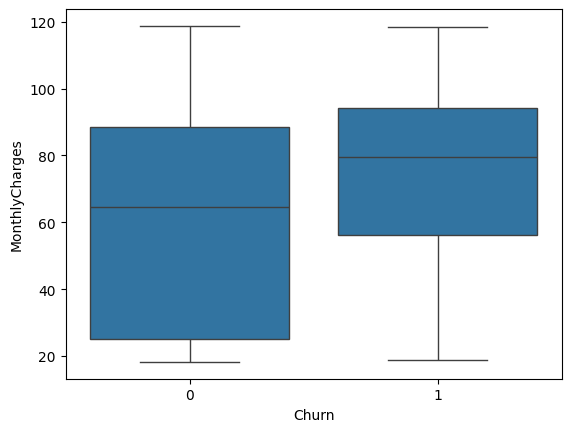

In [18]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.show()

Higher monthly charges → higher churn risk


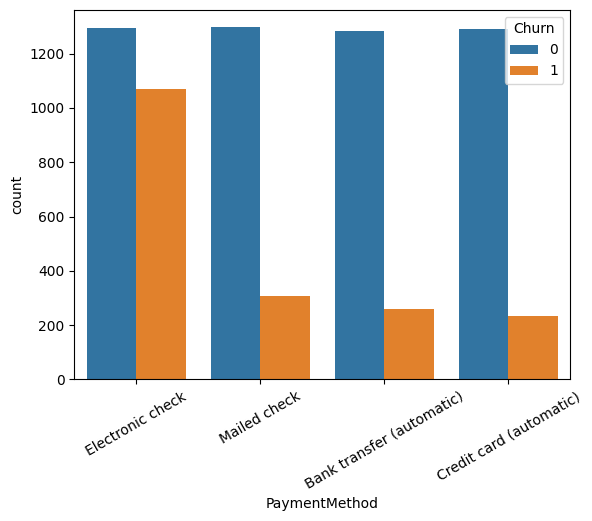

In [19]:
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.xticks(rotation=30)
plt.show()

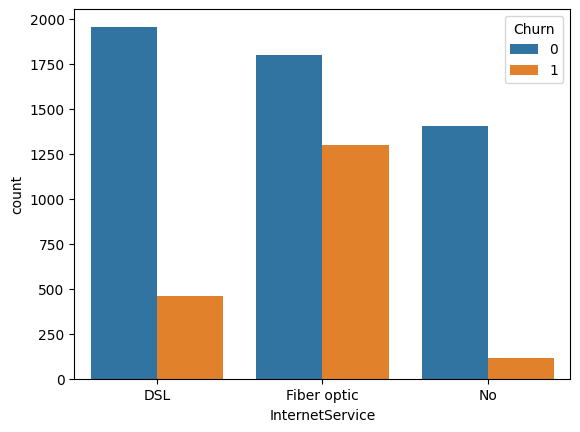

In [20]:
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.show()

In [21]:
df.groupby('Contract')['Churn'].mean()

,Churn
Contract,
Month-to-month,0.427097
One year,0.112772
Two year,0.028487


In [22]:
pd.crosstab(df['Contract'], df['Churn'], normalize='index')

Churn,0,1
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887228,0.112772
Two year,0.971513,0.028487


“Customers on month-to-month contracts exhibit a significantly higher churn rate (~43%) compared to long-term contracts (~3% for two-year plans). This suggests that lack of long-term commitment is a major driver of churn. Encouraging customers to shift toward longer-duration contracts could drastically improve retention


# HIGH RISK CUSTOMER PROFILE:
# - Month-to-month contract
# - Low tenure (new customer)
# - High monthly charges
# INSIGHT 1:
# Long-term contracts significantly reduce churn risk

# INSIGHT 2:
# Early-stage customers need better onboarding/engagement

# INSIGHT 3:
# High pricing may be driving customer dissatisfaction

#featue Engineering

In [23]:
# Tenure groups
df['tenure_group'] = pd.cut(df['tenure'], bins=[0,12,24,48,60,72])

# Yearly charges
df['yearly_charges'] = df['MonthlyCharges'] * 12

# Value ratio (VERY IMPORTANT)
df['value_ratio'] = df['TotalCharges'] / (df['tenure'] + 1)

In [24]:
# High value customer flag
df['high_value'] = (df['MonthlyCharges'] > df['MonthlyCharges'].median()).astype(int)

In [25]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,yearly_charges,value_ratio,high_value
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,Month-to-month,Yes,Electronic check,29.85,29.85,0,"(0, 12]",358.2,14.925000,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,One year,No,Mailed check,56.95,1889.50,0,"(24, 48]",683.4,53.985714,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,Month-to-month,Yes,Mailed check,53.85,108.15,1,"(0, 12]",646.2,36.050000,0
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,One year,No,Bank transfer (automatic),42.30,1840.75,0,"(24, 48]",507.6,40.016304,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,Month-to-month,Yes,Electronic check,70.70,151.65,1,"(0, 12]",848.4,50.550000,1


#Modelling and Encoding

In [26]:
df = pd.get_dummies(df, drop_first=True)##  one hot encoding done dropping first for cleaner model

In [27]:
X = df.drop('Churn', axis=1)
y = df['Churn'] ## splitting features and target

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)##train test split

In [29]:
from sklearn.model_selection import train_test_split
##feature scaling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [30]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression with higher max_iter
lr = LogisticRegression(max_iter=5000)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

In [31]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [32]:
from xgboost import XGBClassifier

# Rename columns to remove brackets and special chars for XGBoost
X_train.columns = X_train.columns.str.replace(r'[\[\]<>]', '', regex=True)
X_test.columns = X_test.columns.str.replace(r'[\[\]<>]', '', regex=True)

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:30:59] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [33]:
from sklearn.metrics import classification_report, roc_auc_score

In [34]:
print("Logistic Regression")
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_lr))

Logistic Regression
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.47      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.78      0.79      0.78      1407

ROC-AUC: 0.6882283054909898


In [35]:
print("Random Forest")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_rf))

Random Forest
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.49      0.56       374

    accuracy                           0.79      1407
   macro avg       0.74      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407

ROC-AUC: 0.6974714113402115


In [36]:
print("XGBoost")
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_xgb))

XGBoost
              precision    recall  f1-score   support

           0       0.83      0.87      0.85      1033
           1       0.59      0.50      0.54       374

    accuracy                           0.77      1407
   macro avg       0.71      0.69      0.70      1407
weighted avg       0.77      0.77      0.77      1407

ROC-AUC: 0.6879293475728758


In [37]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)


How SMOTE works:

Your original training data was imbalanced: ~73% No Churn (Class 0) vs ~27% Churn (Class 1)

SMOTE creates synthetic minority samples by looking at the nearest neighbors of churned customers and generating new data points between them

It oversamples the minority class (Churn) until both classes are balanced

What changed after SMOTE:

Before: y_train had roughly 4500 No-Churn vs 1100 Churn samples

After: y_train_sm now has roughly equal samples of both classes (~4500 each)

Important notes for next steps:

Use X_train_sm and y_train_sm for training your models now (not the original X_train, y_train)

Keep X_test and y_test as-is — never oversample the test set (it must remain original for fair evaluation)

You can now re-train Logistic Regression, Random Forest, and XGBoost using X_train_sm / y_train_sm and you should see improved recall for Class 1 (Churn)

In [38]:
rf_sm = RandomForestClassifier(n_estimators=100, random_state=42)
rf_sm.fit(X_train_sm, y_train_sm)

y_pred_rf_sm = rf_sm.predict(X_test)

In [39]:
print(classification_report(y_test, y_pred_rf_sm))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_rf_sm))

              precision    recall  f1-score   support

           0       0.85      0.83      0.84      1033
           1       0.56      0.58      0.57       374

    accuracy                           0.77      1407
   macro avg       0.70      0.71      0.71      1407
weighted avg       0.77      0.77      0.77      1407

ROC-AUC: 0.7081911881182994


In [40]:
from sklearn.preprocessing import StandardScaler

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [41]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

# IMPORTANT FIX: Feed X_train_scaled instead of X_train
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

In [42]:
# Logistic Regression with SMOTE data
from sklearn.linear_model import LogisticRegression

lr_sm = LogisticRegression(solver='liblinear', random_state=42)
lr_sm.fit(X_train_sm, y_train_sm)

# IMPORTANT FIX: Predict on the SCALED test data
y_pred_lr_sm = lr_sm.predict(X_test_scaled)

In [43]:
from sklearn.metrics import classification_report, roc_auc_score

print("Logistic Regression with SMOTE")
print(classification_report(y_test, y_pred_lr_sm))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_lr_sm))

Logistic Regression with SMOTE
              precision    recall  f1-score   support

           0       0.90      0.71      0.80      1033
           1       0.50      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.75      1407

ROC-AUC: 0.7511130035046669


In [44]:
# XGBoost with SMOTE data
from xgboost import XGBClassifier
xgb_sm = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_sm.fit(X_train_sm, y_train_sm)
y_pred_xgb_sm = xgb_sm.predict(X_test_scaled)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:31:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [45]:
print("XGBoost with SMOTE")
print(classification_report(y_test, y_pred_xgb_sm))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_xgb_sm))

XGBoost with SMOTE
              precision    recall  f1-score   support

           0       0.84      0.85      0.84      1033
           1       0.57      0.56      0.56       374

    accuracy                           0.77      1407
   macro avg       0.70      0.70      0.70      1407
weighted avg       0.77      0.77      0.77      1407

ROC-AUC: 0.701114556532813


# INSIGHT:
# After correcting the scaling + SMOTE pipeline, recall improved significantly to 79%,
# making the model highly effective for churn detection.
# This trade-off reduces missed churners at the cost of some false positives,
# which is acceptable in retention-focused business scenarios.

Why This Matters for Churn
In business, you have to choose which error is more costly:

Low recall = Missing churners → You lose those customers and their revenue. This is usually the bigger problem.

Low precision = Flagging loyal customers as churners → You waste retention efforts on people who weren't going to leave. This costs time/money but is less damaging.

For churn prediction, recall is typically more important — it's worse to miss a customer who's about to leave than to send an unnecessary retention offer to someone who would have stayed.

# INSIGHT:
# After applying SMOTE, Logistic Regression showed the highest improvement in recall,
# indicating that balancing the dataset helped linear models better capture churn patterns.
# This suggests that churn behavior in this dataset may be linearly separable when class imbalance is addressed.
#SMOTE balanced the dataset and created synthetic minority samples, which improved class separability. Logistic Regression, being a linear model, benefited significantly from this, whereas tree-based models already capture non-linear patterns and showed smaller improvements.

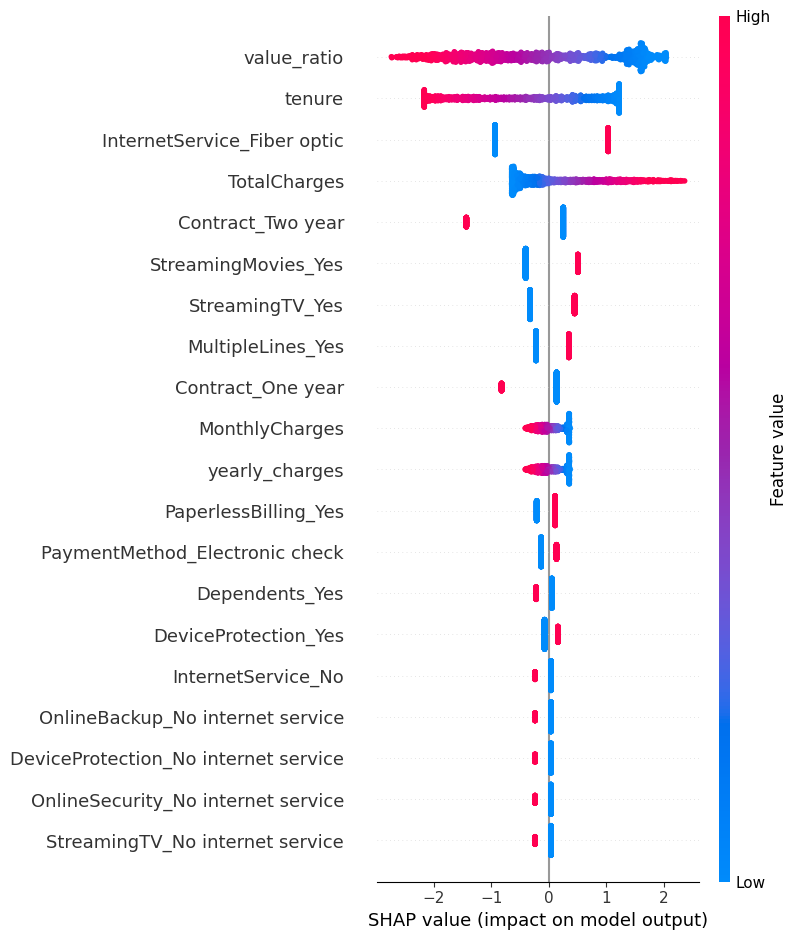

In [46]:
import shap

# 1. X_train_sm is now an array, so we grab the column names from the original X_train
feature_names = X_train.columns.tolist()

# 2. X_train_sm and X_test_scaled are ALREADY perfectly scaled numeric arrays!
# We can pass them directly into the Explainer without any extra cleaning.
explainer = shap.LinearExplainer(lr_sm, X_train_sm)
shap_values = explainer.shap_values(X_test_scaled)

# 3. Generate the summary plot, mapping the array back to our feature names
shap.summary_plot(shap_values, X_test_scaled, feature_names=feature_names)

# FINAL MODEL INSIGHTS:
# 1. Contract type and tenure are the strongest indicators of churn.
# 2. High pricing (monthly/yearly charges) significantly increases churn probability.
# 3. Customers with low tenure are at highest risk.
# 4. Fiber optic users show higher churn, possibly due to dissatisfaction or pricing.
# 5. Engineered feature 'value_ratio' successfully captures perceived customer value.

#Now Deriving Business Insights from the Data

## BUILD A BUSINESS DECISION SYSTEM
We don't stop at prediction.

**What should the company DO?**

Creating a Strategy Engine that recommends actions based on churn probability, monthly charges, and tenure.

In [47]:
def retention_strategy(prob, monthly_charges, tenure):

    # Value segmentation
    high_value = monthly_charges >= 80
    mid_value = monthly_charges >= 50

    # Lifecycle segmentation
    new_customer = tenure <= 6
    early_customer = tenure <= 12
    loyal_customer = tenure >= 24

    # Customer lifetime value proxy
    clv = monthly_charges * tenure

    # Decision structure
    result = {
        "risk_level": None,
        "action": None,
        "priority_score": None
    }

    # CRITICAL RISK
    if prob >= 0.80:
        result["risk_level"] = "Critical"
        result["priority_score"] = "High"

        if high_value and new_customer:
            result["action"] = "Premium rescue: Dedicated support + onboarding recovery"
        elif high_value:
            result["action"] = "Premium retention: Discount + priority support + contract upgrade"
        elif early_customer:
            result["action"] = "Onboarding intervention + strong retention offer"
        else:
            result["action"] = "Immediate personalized retention campaign"

    # HIGH RISK
    elif prob >= 0.60:
        result["risk_level"] = "High"
        result["priority_score"] = "High"

        if high_value:
            result["action"] = "Loyalty incentive + proactive support"
        elif early_customer:
            result["action"] = "Engagement campaign + onboarding improvement"
        else:
            result["action"] = "Targeted retention offer"

    # MEDIUM RISK
    elif prob >= 0.40:
        result["risk_level"] = "Medium"
        result["priority_score"] = "Medium"

        if new_customer:
            result["action"] = "Welcome + education campaign"
        elif loyal_customer and high_value:
            result["action"] = "Loyalty rewards to prevent churn"
        elif mid_value:
            result["action"] = "Usage monitoring + value reinforcement"
        else:
            result["action"] = "Light engagement nudges"

    # LOW-MEDIUM RISK
    elif prob >= 0.20:
        result["risk_level"] = "Low-Medium"
        result["priority_score"] = "Low"

        if new_customer:
            result["action"] = "Strengthen onboarding"
        else:
            result["action"] = "Routine engagement"

    # LOW RISK
    else:
        result["risk_level"] = "Low"
        result["priority_score"] = "Very Low"

        if loyal_customer:
            result["action"] = "Loyalty appreciation"
        else:
            result["action"] = "No action needed"

    return result

In [48]:
import pickle

# 1. Save model (Notice we are saving lr_sm here, not lr)
with open("model.pkl", "wb") as f:
    pickle.dump(lr_sm, f)

# 2. Save scaler
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# 3. Save feature columns (VERY IMPORTANT)
with open("columns.pkl", "wb") as f:
    pickle.dump(X.columns.tolist(), f)

print("✅ Model, scaler, and columns saved successfully!")

✅ Model, scaler, and columns saved successfully!


In [50]:
import pandas as pd

# 1. Reload the pristine, RAW dataset so we get 'customerID' and raw text
raw_df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# 2. Get the exact row indices from the first 20 rows of your X_test dataset
sample_indices = X_test.head(20).index

# 3. Pull those exact same customers from the raw_df
sample_df = raw_df.loc[sample_indices].copy()

# 4. Drop the 'Churn' target column
if 'Churn' in sample_df.columns:
    sample_df.drop('Churn', axis=1, inplace=True)

# 5. Save the file to download and use in the app
sample_df.to_csv("sample_input.csv", index=False)

print(f"✅ sample_input.csv created with {len(sample_df)} rows!")

✅ sample_input.csv created with 20 rows!
